In [1]:
# DAY 29 - CUSTOMER SEGMENTATION WITH K-MEANS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the cleaned Sales dataset

df = pd.read_csv("../cleaned_dataset.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (51290, 23)


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,shipping_days,profit_margin
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,"Tenex Lockers, Blue",408.0,2,0.0,106.140,35.46,Medium,2011,5,26.014706
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,"Acme Trimmer, High Speed",120.0,3,0.1,36.036,9.72,Medium,2011,7,30.030000
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,"Tenex Box, Single Width",66.0,4,0.0,29.640,8.17,High,2011,4,44.909091
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,"Enermax Note Cards, Premium",45.0,3,0.5,-26.055,4.82,High,2011,4,-57.900000
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,"Eldon Light Bulb, Duo Pack",114.0,5,0.1,37.770,4.70,Medium,2011,7,33.131579


In [3]:
# Create customer-level behavior data

customer_data = df.groupby("customer_name").agg(
    total_sales=("sales", "sum"),
    total_quantity=("quantity", "sum"),
    total_profit=("profit", "sum"),
    average_discount=("discount", "mean"),
    average_shipping_days=("shipping_days", "mean"),
    number_of_orders=("order_id", "count")
).reset_index()

print("Customer-level data created successfully!")

print("Number of customers:", len(customer_data))

customer_data.head()

Customer-level data created successfully!
Number of customers: 795


,customer_name,total_sales,total_quantity,total_profit,average_discount,average_shipping_days,number_of_orders
0,Aaron Bergman,24646.0,301,4683.20800,0.110112,3.707865,89
1,Aaron Hawkins,20759.0,231,2450.92904,0.160929,3.464286,56
2,Aaron Smayling,14207.0,211,369.16180,0.167667,4.433333,60
3,Adam Bellavance,20189.0,262,4979.97690,0.131765,3.514706,68
4,Adam Hart,21720.0,293,1902.03342,0.093238,3.654762,84


In [4]:
# Select numerical features for customer segmentation

feature_columns = [
    "total_sales",
    "total_quantity",
    "total_profit",
    "average_discount",
    "average_shipping_days",
    "number_of_orders"
]

X = customer_data[feature_columns]

print("Customer behavior features selected!")

print("\nFeatures used:")
print(feature_columns)

print("\nFeature data shape:", X.shape)

X.head()

Customer behavior features selected!

Features used:
['total_sales', 'total_quantity', 'total_profit', 'average_discount', 'average_shipping_days', 'number_of_orders']

Feature data shape: (795, 6)


,total_sales,total_quantity,total_profit,average_discount,average_shipping_days,number_of_orders
0,24646.0,301,4683.20800,0.110112,3.707865,89
1,20759.0,231,2450.92904,0.160929,3.464286,56
2,14207.0,211,369.16180,0.167667,4.433333,60
3,20189.0,262,4979.97690,0.131765,3.514706,68
4,21720.0,293,1902.03342,0.093238,3.654762,84


In [5]:
# Scale the customer behavior features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Customer features scaled successfully!")

print("Scaled data shape:", X_scaled.shape)

print("\nFirst 5 scaled rows:")
print(X_scaled[:5])

Customer features scaled successfully!
Scaled data shape: (795, 6)

First 5 scaled rows:
[[ 1.67923479  1.51782672  1.83675336 -0.73064577 -0.72146871  1.8239146 ]
 [ 0.93267132  0.13273486  0.3906802   0.39657357 -1.38947874 -0.63436434]
 [-0.32575005 -0.26300567 -0.95789127  0.54603987  1.26810801 -0.33639113]
 [ 0.82319327  0.74613269  2.02900063 -0.2503474  -1.2512028   0.25955528]
 [ 1.11724747  1.35953051  0.03510492 -1.10495539 -0.86710297  1.45144809]]


In [6]:
# Experiment with different numbers of clusters

cluster_results = []

for k in range(2, 7):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_scaled, labels)
    
    cluster_results.append({
        "Clusters": k,
        "Inertia": inertia,
        "Silhouette Score": silhouette
    })

cluster_results = pd.DataFrame(cluster_results)

cluster_results["Inertia"] = cluster_results["Inertia"].round(2)
cluster_results["Silhouette Score"] = cluster_results["Silhouette Score"].round(3)

print("Cluster experiments completed!")
print(cluster_results)

Cluster experiments completed!
   Clusters  Inertia  Silhouette Score
0         2  3376.46             0.256
1         3  2911.63             0.208
2         4  2595.04             0.178
3         5  2362.85             0.175
4         6  2159.28             0.176


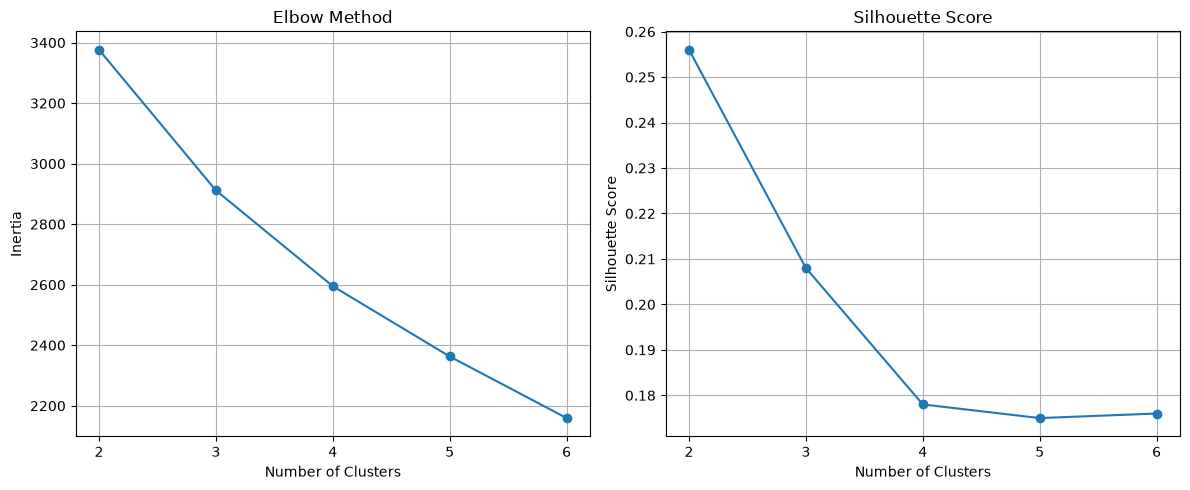

In [7]:
# Visualize cluster evaluation

plt.figure(figsize=(12, 5))

# Elbow Method
plt.subplot(1, 2, 1)
plt.plot(
    cluster_results["Clusters"],
    cluster_results["Inertia"],
    marker="o"
)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(cluster_results["Clusters"])
plt.grid(True)

# Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(
    cluster_results["Clusters"],
    cluster_results["Silhouette Score"],
    marker="o"
)
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.xticks(cluster_results["Clusters"])
plt.grid(True)

plt.tight_layout()
plt.show()

In [8]:
# Select the best number of clusters

best_k = int(
    cluster_results.loc[
        cluster_results["Silhouette Score"].idxmax(),
        "Clusters"
    ]
)

print("Selected number of clusters:", best_k)

Selected number of clusters: 2


In [9]:
# Apply K-Means with the selected number of clusters

final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

customer_data["cluster"] = final_kmeans.fit_predict(X_scaled)

print("Final K-Means clustering completed!")

print("\nNumber of customers in each cluster:")
print(
    customer_data["cluster"]
    .value_counts()
    .sort_index()
)

Final K-Means clustering completed!

Number of customers in each cluster:
cluster
0    338
1    457
Name: count, dtype: int64


In [10]:
# Create a profile for each customer cluster

cluster_profile = customer_data.groupby("cluster")[feature_columns].mean().round(2)

cluster_profile["customer_count"] = (
    customer_data.groupby("cluster").size()
)

print("Customer cluster profiles:")
print(cluster_profile)

Customer cluster profiles:
         total_sales  total_quantity  total_profit  average_discount  \
cluster                                                                
0           20109.22          267.53       2616.06              0.14   
1           12792.09          192.31       1279.66              0.15   

         average_shipping_days  number_of_orders  customer_count  
cluster                                                           
0                         3.95             75.81             338  
1                         3.99             56.16             457  


In [11]:
# Save customer cluster profile

cluster_profile.to_csv("customer_cluster_profile.csv")

print("Customer cluster profile saved successfully!")

Customer cluster profile saved successfully!


In [12]:
# Reduce customer features to 2 dimensions using PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA completed successfully!")
print("Explained variance by component:")
print(pca.explained_variance_ratio_)

PCA completed successfully!
Explained variance by component:
[0.46252438 0.21647037]


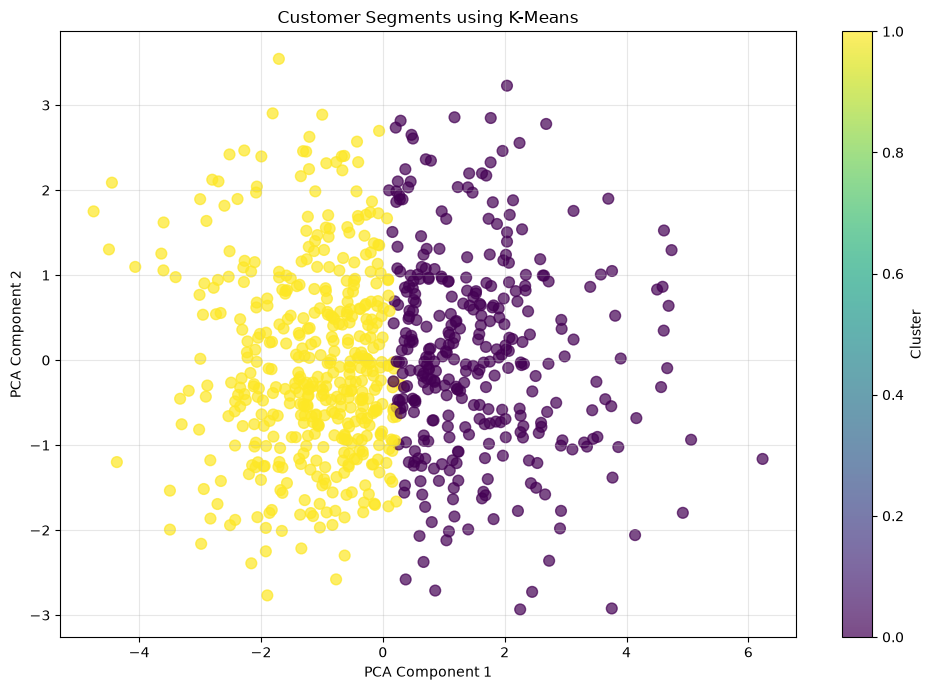

In [13]:
# Visualize customer segments

plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=customer_data["cluster"],
    cmap="viridis",
    s=60,
    alpha=0.7
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Customer Segments using K-Means")
plt.colorbar(label="Cluster")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("customer_segments.png", dpi=300, bbox_inches="tight")

plt.show()

In [14]:
# Save cluster evaluation results

cluster_results.to_csv(
    "cluster_evaluation.csv",
    index=False
)

print("Cluster evaluation results saved successfully!")

Cluster evaluation results saved successfully!


In [15]:
# Generate business insights from customer clusters

print("========== CUSTOMER SEGMENT INSIGHTS ==========\n")

for feature in feature_columns:
    highest_cluster = cluster_profile[feature].idxmax()
    lowest_cluster = cluster_profile[feature].idxmin()

    print(f"{feature}:")
    print(
        f"  Highest → Cluster {highest_cluster} "
        f"({cluster_profile.loc[highest_cluster, feature]})"
    )
    print(
        f"  Lowest  → Cluster {lowest_cluster} "
        f"({cluster_profile.loc[lowest_cluster, feature]})"
    )
    print()

========== CUSTOMER SEGMENT INSIGHTS ==========

total_sales:
  Highest → Cluster 0 (20109.22)
  Lowest  → Cluster 1 (12792.09)

total_quantity:
  Highest → Cluster 0 (267.53)
  Lowest  → Cluster 1 (192.31)

total_profit:
  Highest → Cluster 0 (2616.06)
  Lowest  → Cluster 1 (1279.66)

average_discount:
  Highest → Cluster 1 (0.15)
  Lowest  → Cluster 0 (0.14)

average_shipping_days:
  Highest → Cluster 1 (3.99)
  Lowest  → Cluster 0 (3.95)

number_of_orders:
  Highest → Cluster 0 (75.81)
  Lowest  → Cluster 1 (56.16)



In [17]:
# Create business insight report

report_lines = []

report_lines.append("# Day 29 - Customer Segmentation Business Insights\n")
report_lines.append(f"## Number of Customer Segments: {best_k}\n")

report_lines.append(
    "Customer behavior was analyzed using K-Means clustering based on "
    "sales, quantity, profit, discount, shipping time, and order frequency.\n"
)

report_lines.append("## Cluster Profiles\n")

for cluster in sorted(customer_data["cluster"].unique()):
    row = cluster_profile.loc[cluster]

    report_lines.append(f"\n### Cluster {cluster}\n")
    report_lines.append(
        f"- Customers: {int(row['customer_count'])}"
    )
    report_lines.append(
        f"- Average total sales: {row['total_sales']}"
    )
    report_lines.append(
        f"- Average total quantity: {row['total_quantity']}"
    )
    report_lines.append(
        f"- Average total profit: {row['total_profit']}"
    )
    report_lines.append(
        f"- Average discount: {row['average_discount']}"
    )
    report_lines.append(
        f"- Average shipping days: {row['average_shipping_days']}"
    )
    report_lines.append(
        f"- Average number of orders: {row['number_of_orders']}"
    )

report_lines.append("\n## Business Takeaway\n")

report_lines.append(
    "K-Means clustering revealed groups of customers with different "
    "purchasing and behavioral patterns. These customer segments can "
    "help businesses understand customer behavior and support more "
    "targeted marketing, pricing, and customer-service strategies."
)

with open("business_insights.md", "w", encoding="utf-8") as file:
    file.write("\n".join(report_lines))

print("Business insight report created successfully!")
print("File: business_insights.md")

Business insight report created successfully!
File: business_insights.md


In [18]:
# Display final customer segment summary

final_summary = cluster_profile.copy()

final_summary = final_summary[
    [
        "customer_count",
        "total_sales",
        "total_quantity",
        "total_profit",
        "average_discount",
        "average_shipping_days",
        "number_of_orders"
    ]
]

print("========== FINAL CUSTOMER SEGMENT SUMMARY ==========")
display(final_summary)

========== FINAL CUSTOMER SEGMENT SUMMARY ==========


,customer_count,total_sales,total_quantity,total_profit,average_discount,average_shipping_days,number_of_orders
cluster,,,,,,,
0,338,20109.22,267.53,2616.06,0.14,3.95,75.81
1,457,12792.09,192.31,1279.66,0.15,3.99,56.16


In [19]:
# Save final customer segment summary

final_summary.to_csv(
    "final_customer_segment_summary.csv"
)

print("Final customer segment summary saved successfully!")

Final customer segment summary saved successfully!


In [20]:
# Check Day 29 output files

import os

print("========== DAY 29 FILES ==========\n")

for file in sorted(os.listdir(".")):
    print(file)

========== DAY 29 FILES ==========

README.md
business_insights.md
cluster_evaluation.csv
customer_cluster_profile.csv
customer_segments.png
day29.ipynb
final_customer_segment_summary.csv
